In [1]:
import os
import sys
import subprocess

os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", "1")
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "1")

try:
    import tensorflow as tf
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [2]:
dataset_root = r"E:\AI Project\AgriMind_Project\datasets\Tomato leaf disease detection"
train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "val")

print("Dataset root exists:", os.path.exists(dataset_root))
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Dataset root exists: True
Train exists: True
Test exists: True


Download Dataset


In [3]:
!ls /content/datasets

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
!find /content/datasets -maxdepth 3 -type d

FIND: Invalid switch


In [5]:
train_dir = "/content/datasets/tomato/train"
test_dir = "/content/datasets/tomato/val"

In [6]:
import os

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Train exists: False
Test exists: False


Load dataset manually


In [8]:
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32

# resolve dataset paths (fallback to dataset_root if the Colab paths don't exist)
if not os.path.exists(train_dir):
    alt_train = os.path.join(dataset_root, "train")
    if os.path.exists(alt_train):
        train_dir = alt_train
    else:
        raise FileNotFoundError(f"Train directory not found: {train_dir}. Tried fallback: {alt_train}")

if not os.path.exists(test_dir):
    alt_test = os.path.join(dataset_root, "val")
    if os.path.exists(alt_test):
        test_dir = alt_test
    else:
        # test set missing is non-fatal here, but inform the user
        print(f"Warning: Test directory not found: {test_dir}. Tried fallback: {alt_test}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 10000 files belonging to 10 classes.
Using 8500 files for training.
Found 10000 files belonging to 10 classes.
Using 1500 files for validation.
Found 584 files belonging to 6 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Number of classes: 10


Normalize images


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

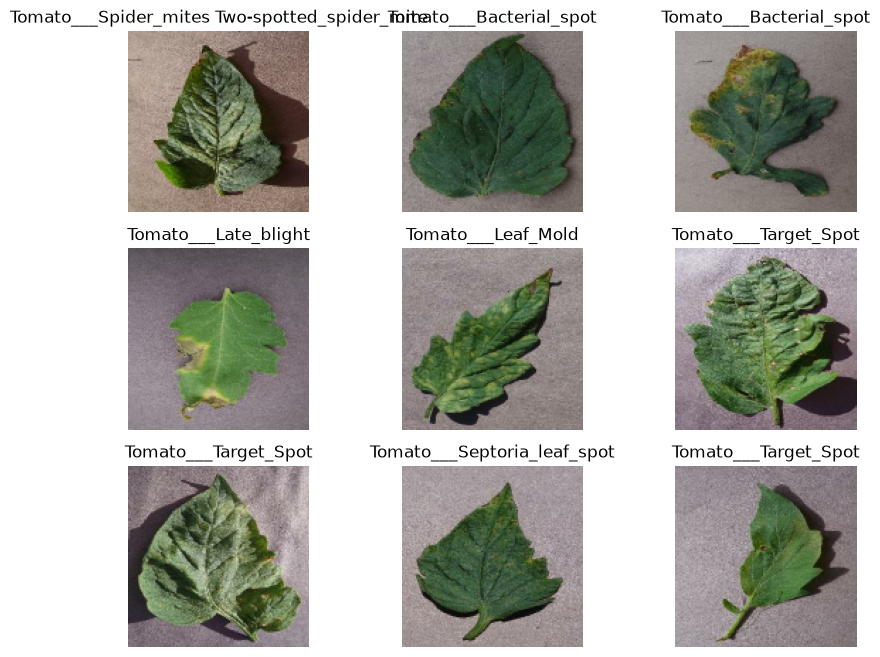

In [10]:
import sys, subprocess

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

Create CNN Model

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Train CNN Model

In [12]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


e:\AI Project\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


266/266 ━━━━━━━━━━━━━━━━━━━━ 112s 418ms/step - accuracy: 0.5011 - loss: 1.4154 - val_accuracy: 0.7220 - val_loss: 0.7988
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 111s 415ms/step - accuracy: 0.7441 - loss: 0.7312 - val_accuracy: 0.8000 - val_loss: 0.5704
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 112s 423ms/step - accuracy: 0.8171 - loss: 0.5392 - val_accuracy: 0.8700 - val_loss: 0.3697
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 112s 419ms/step - accuracy: 0.8500 - loss: 0.4286 - val_accuracy: 0.8727 - val_loss: 0.3584
Epoch 5/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 111s 418ms/step - accuracy: 0.8768 - loss: 0.3674 - val_accuracy: 0.8833 - val_loss: 0.3376
Epoch 6/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.8965 - loss: 0.2978 - val_accuracy: 0.8993 - val_loss: 0.2823
Epoch 7/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 373s 1s/step - accuracy: 0.8969 - loss: 0.3028 - val_accuracy: 0.8960 - val_loss: 0.2930
Epoch 8/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.9168 - loss: 0.2323 - val_

In [13]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Final Training Accuracy   :", train_acc)
print("Final Validation Accuracy :", val_acc)

print("Final Training Loss       :", train_loss)
print("Final Validation Loss     :", val_loss)

Final Training Accuracy   : 0.9368235468864441
Final Validation Accuracy : 0.9113333225250244
Final Training Loss       : 0.18644967675209045
Final Validation Loss     : 0.2744283974170685


Accuracy Graph

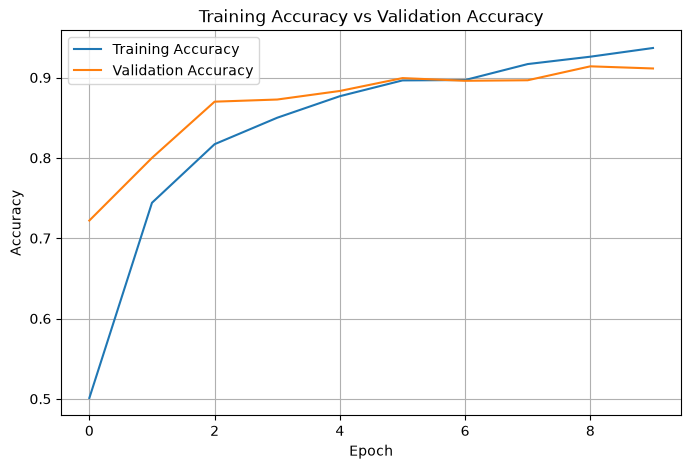

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Loss Graph

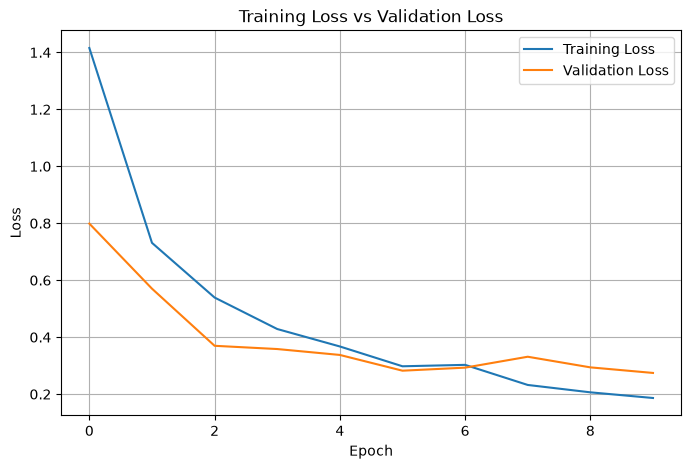

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Test model accuracy

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.8647 - loss: 0.4181
Test Loss: 0.4180973768234253
Test Accuracy: 0.8647260069847107


In [19]:
import numpy as np
import sys
import subprocess

try:
    from sklearn.metrics import classification_report, confusion_matrix
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.metrics import classification_report, confusion_matrix

try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.93      0.95      0.94       100
                        Tomato___Early_blight       0.82      0.80      0.81       1

e:\AI Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\AI Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\AI Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


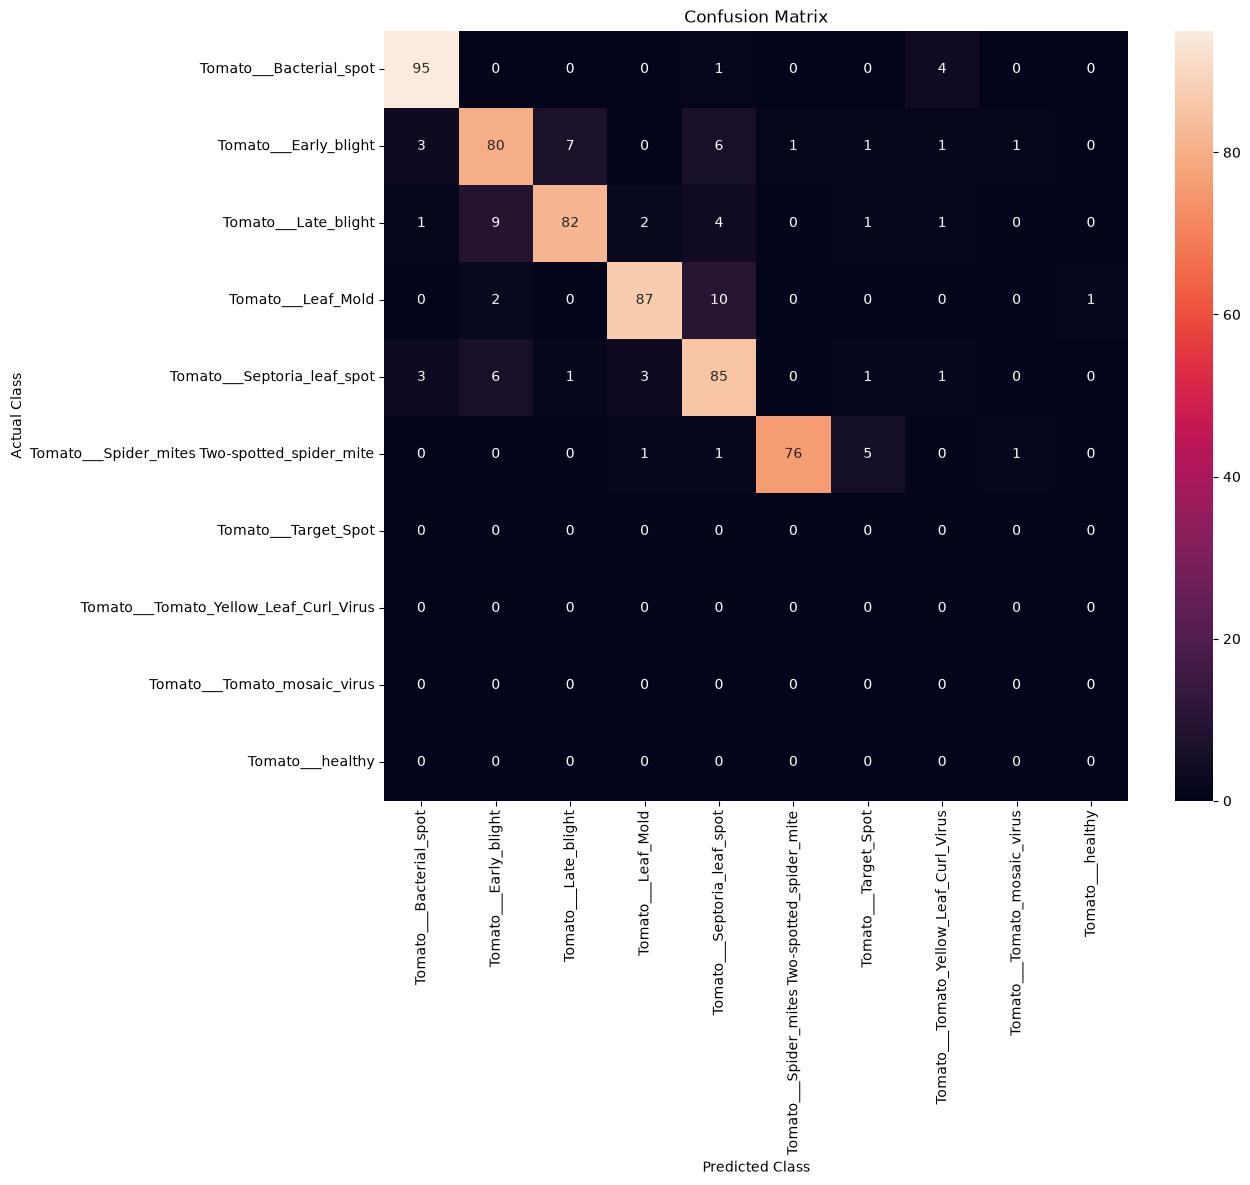

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [21]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

y_true = []
y_pred = []

# Get actual labels and predicted labels from test dataset
for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Calculate overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("Final Evaluation Results")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nDetailed Classification Report")
print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Final Evaluation Results
------------------------
Accuracy : 0.8647260273972602
Precision: 0.8948961013005295
Recall   : 0.8647260273972602
F1-score : 0.878730927450826

Detailed Classification Report
                                               precision   

In [24]:
import os
import json
import pandas as pd

# Main project folder
PROJECT_DIR = r"E:\AI Project\AgriMind_Project"

# Phase-specific folders
PHASE_NAME = "phase1_cnn"

MODEL_DIR = os.path.join(PROJECT_DIR, "models", PHASE_NAME)
RESULTS_DIR = os.path.join(PROJECT_DIR, "results", PHASE_NAME)
SCREENSHOTS_DIR = os.path.join(PROJECT_DIR, "screenshots", PHASE_NAME)

# Create folders if missing
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

# Save trained CNN model
keras_model_path = os.path.join(MODEL_DIR, "agrimind_tomato_cnn_model.keras")
h5_model_path = os.path.join(MODEL_DIR, "agrimind_tomato_cnn_model.h5")

model.save(keras_model_path)
model.save(h5_model_path)

# Save class names
class_names_path = os.path.join(MODEL_DIR, "class_names.json")

with open(class_names_path, "w") as f:
    json.dump(class_names, f)

# Save evaluation metrics
phase1_results = pd.DataFrame([{
    "Module": "Disease Detection",
    "Model": "Centralized CNN",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Test Loss": test_loss
}])

results_path = os.path.join(RESULTS_DIR, "phase1_cnn_results.csv")
phase1_results.to_csv(results_path, index=False)

print("Phase 1 CNN files saved successfully.")
print("Keras model saved at:", keras_model_path)
print("H5 model saved at:", h5_model_path)
print("Class names saved at:", class_names_path)
print("Results saved at:", results_path)

Phase 1 CNN files saved successfully.
Keras model saved at: E:\AI Project\AgriMind_Project\models\phase1_cnn\agrimind_tomato_cnn_model.keras
H5 model saved at: E:\AI Project\AgriMind_Project\models\phase1_cnn\agrimind_tomato_cnn_model.h5
Class names saved at: E:\AI Project\AgriMind_Project\models\phase1_cnn\class_names.json
Results saved at: E:\AI Project\AgriMind_Project\results\phase1_cnn\phase1_cnn_results.csv
